# Credit Card Fraud Detection — Exploratory Data Analysis

This notebook contains the **EDA phase** for a machine learning project on **credit card fraud detection**.  
It is structured for clean presentation on GitHub and can be used as the first notebook in the project workflow.

--- 


## 1. Project Overview

The goal of this project is to explore a real-world credit card transaction dataset and understand the data before building machine learning models for fraud detection.

### Objectives
- Understand the dataset structure and feature types
- Check for missing values and data quality issues
- Analyze the distribution of the target variable
- Explore the behavior of important variables such as **Time** and **Amount**
- Compare fraud and non-fraud transactions
- Identify features that are most related to fraud
- Prepare insights that will guide preprocessing and modeling

### Dataset Summary
This dataset contains anonymized credit card transactions and a binary target variable:
- **Class = 0** → Non-fraud transaction
- **Class = 1** → Fraud transaction


In [1]:
# !pip install numpy pandas matplotlib seaborn ipython

## 2. Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")


## 3. Load Dataset

In [3]:
# Load dataset
df = pd.read_csv("../data/raw/creditcard.csv")

print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows  {df.shape[1]} columns")

df.head()

Dataset loaded successfully.
Shape: 284,807 rows  31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


## 4. Dataset Shape and Columns

In [4]:
# Basic dataset structure
print("Rows   :", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())


Rows   : 284807
Columns: 31

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [5]:
# Quick structural overview
info_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.notnull().sum().values,
    "Missing Values": df.isnull().sum().values
})

info_df


,Column,Data Type,Non-Null Count,Missing Values
0,Time,float64,284807,0
1,V1,float64,284807,0
2,V2,float64,284807,0
3,V3,float64,284807,0
4,V4,float64,284807,0
5,V5,float64,284807,0
6,V6,float64,284807,0
7,V7,float64,284807,0
8,V8,float64,284807,0
9,V9,float64,284807,0


## 5. Data Types and Missing Values

In [6]:
# Data types
df.dtypes


Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [7]:
# Missing values summary
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage (%)": (missing_values / len(df)) * 100
})

missing_summary = missing_summary.round(2)
print("Missing Values Summary:\n")
display(missing_summary)
print("\n" + "="*50 + "\n")
missing_filtered = missing_summary[missing_summary["Missing Count"] > 0]

if missing_filtered.empty:
    print("✅ No missing values found in the dataset.")
else:
    print("⚠️ Columns with missing values:\n")
    display(missing_filtered)

Missing Values Summary:



,Missing Count,Missing Percentage (%)
Time,0,0.0000
V1,0,0.0000
V2,0,0.0000
V3,0,0.0000
V4,0,0.0000
V5,0,0.0000
V6,0,0.0000
V7,0,0.0000
V8,0,0.0000
V9,0,0.0000




✅ No missing values found in the dataset.


In [8]:
total_missing = int(df.isnull().sum().sum())
print(f"Total missing values in the dataset: {total_missing}")


Total missing values in the dataset: 0


## 6. Target Variable Distribution

In [9]:
class_counts = df["Class"].value_counts().sort_index()
class_percentages = df["Class"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})
target_summary.index = ["Non-Fraud (0)", "Fraud (1)"]
target_summary


,Count,Percentage
Non-Fraud (0),284315,99.8273
Fraud (1),492,0.1727


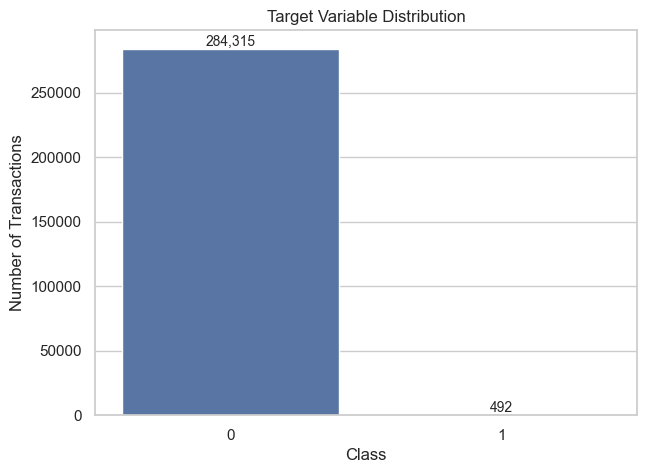

In [10]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x="Class", data=df)
plt.title("Target Variable Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.show()


In [11]:
fraud_rate = df["Class"].mean() * 100
print(f"Fraud transactions: {int(df['Class'].sum()):,}")
print(f"Non-fraud transactions: {int((df['Class'] == 0).sum()):,}")
print(f"Fraud rate: {fraud_rate:.4f}%")


Fraud transactions: 492
Non-fraud transactions: 284,315
Fraud rate: 0.1727%


## 7. Descriptive Statistics

In [12]:
# Overall descriptive statistics
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Time,"284,807.0000","94,813.8596","47,488.1460",0.0000,"54,201.5000","84,692.0000","139,320.5000","172,792.0000"
V1,"284,807.0000",0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,"284,807.0000",0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,"284,807.0000",-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,"284,807.0000",0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,"284,807.0000",0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,"284,807.0000",0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,"284,807.0000",-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,"284,807.0000",0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,"284,807.0000",-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


In [13]:
# Focus on Time and Amount for easier interpretation
df[["Time", "Amount"]].describe().T


,count,mean,std,min,25%,50%,75%,max
Time,"284,807.0000","94,813.8596","47,488.1460",0.0000,"54,201.5000","84,692.0000","139,320.5000","172,792.0000"
Amount,"284,807.0000",88.3496,250.1201,0.0000,5.6000,22.0000,77.1650,"25,691.1600"


## 8. Exploratory Analysis of Time and Amount

In [14]:
# Convert Time from seconds into hours for easier interpretation
df["Time_Hours"] = df["Time"] / 3600

df[["Time", "Time_Hours", "Amount"]].head()


,Time,Time_Hours,Amount
0,0.0000,0.0000,149.6200
1,0.0000,0.0000,2.6900
2,1.0000,0.0003,378.6600
3,1.0000,0.0003,123.5000
4,2.0000,0.0006,69.9900


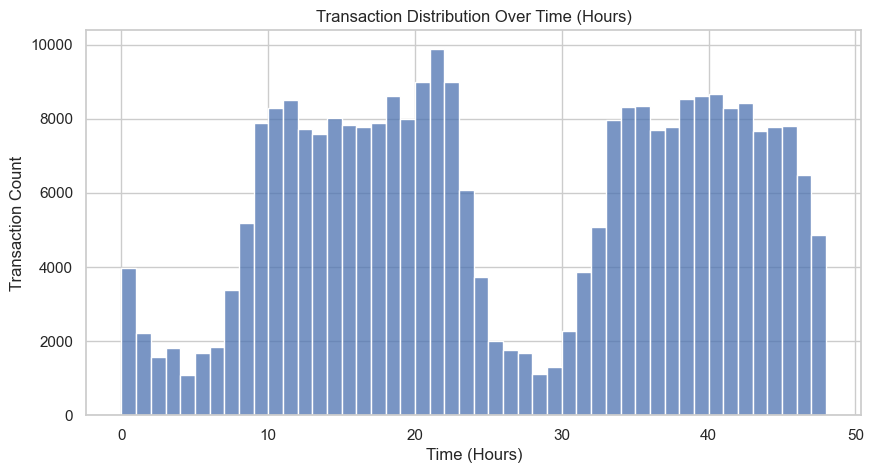

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Time_Hours"], bins=48, kde=False)
plt.title("Transaction Distribution Over Time (Hours)")
plt.xlabel("Time (Hours)")
plt.ylabel("Transaction Count")
plt.show()


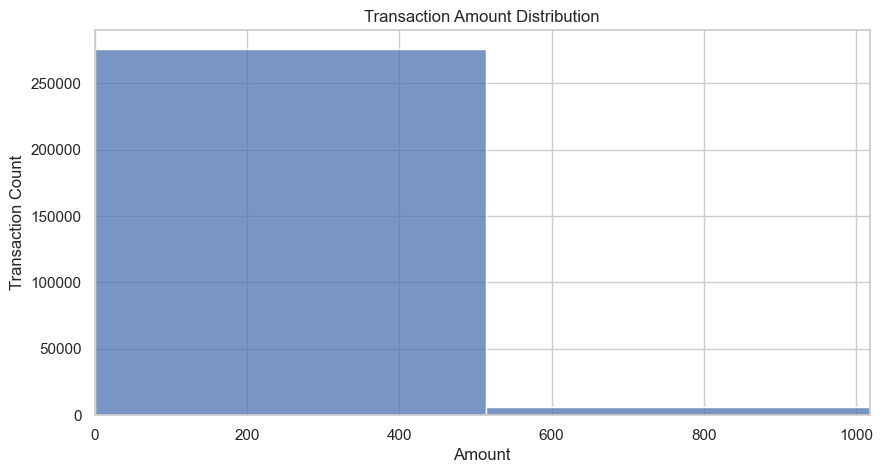

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Amount"], bins=50, kde=False)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Transaction Count")
plt.xlim(0, df["Amount"].quantile(0.99))  # trim extreme outliers for visibility
plt.show()


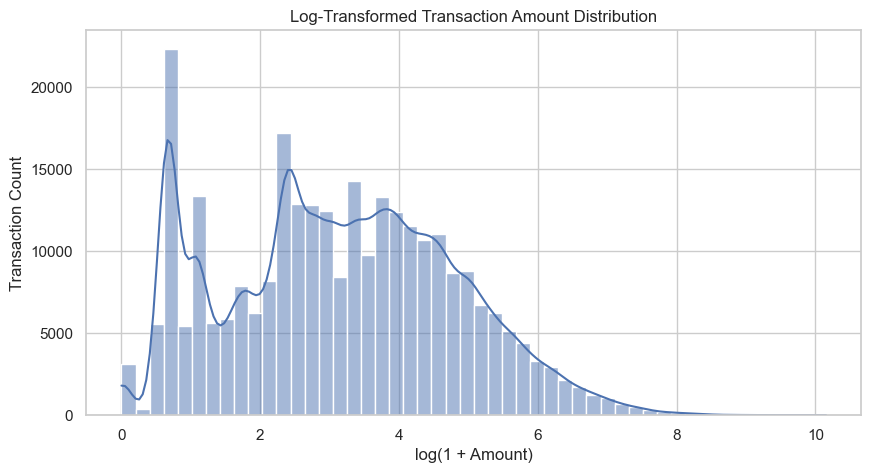

In [17]:
# Log transform Amount for better visualization
df["Log_Amount"] = np.log1p(df["Amount"])

plt.figure(figsize=(10, 5))
sns.histplot(df["Log_Amount"], bins=50, kde=True)
plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("log(1 + Amount)")
plt.ylabel("Transaction Count")
plt.show()


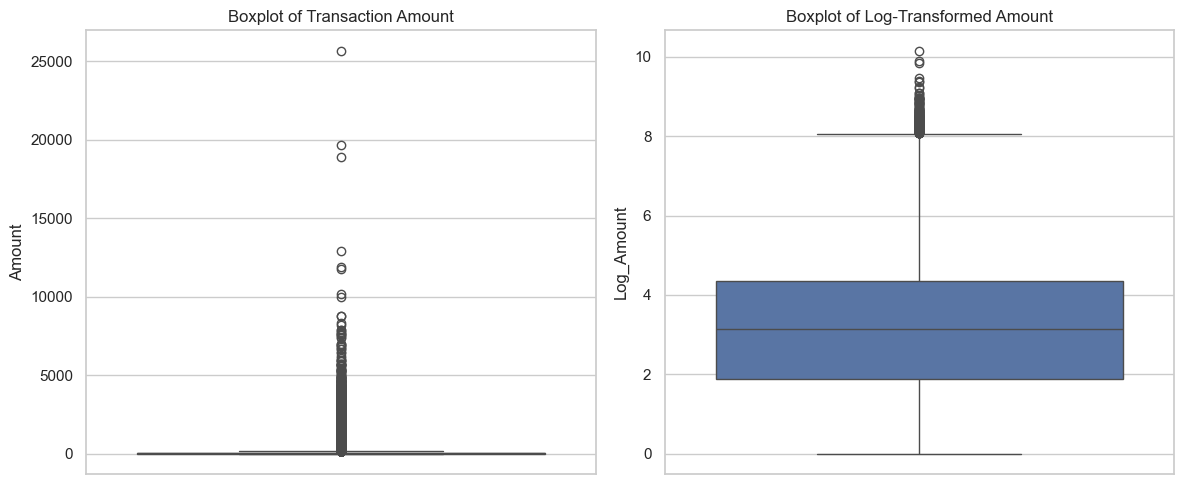

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df["Amount"], ax=axes[0])
axes[0].set_title("Boxplot of Transaction Amount")

sns.boxplot(y=df["Log_Amount"], ax=axes[1])
axes[1].set_title("Boxplot of Log-Transformed Amount")

plt.tight_layout()
plt.show()


## 9. Fraud vs Non-Fraud Comparison

In [19]:
comparison_stats = df.groupby("Class")[["Time", "Amount"]].agg(["count", "mean", "median", "std", "min", "max"])
comparison_stats


Time                                                            \
        count        mean      median         std      min          max   
Class                                                                     
0      284315 94,838.2023 84,711.0000 47,484.0158   0.0000 172,792.0000   
1         492 80,746.8069 75,568.5000 47,835.3651 406.0000 170,348.0000   

       Amount                                               
        count     mean  median      std    min         max  
Class                                                       
0      284315  88.2910 22.0000 250.1051 0.0000 25,691.1600  
1         492 122.2113  9.2500 256.6833 0.0000  2,125.8700

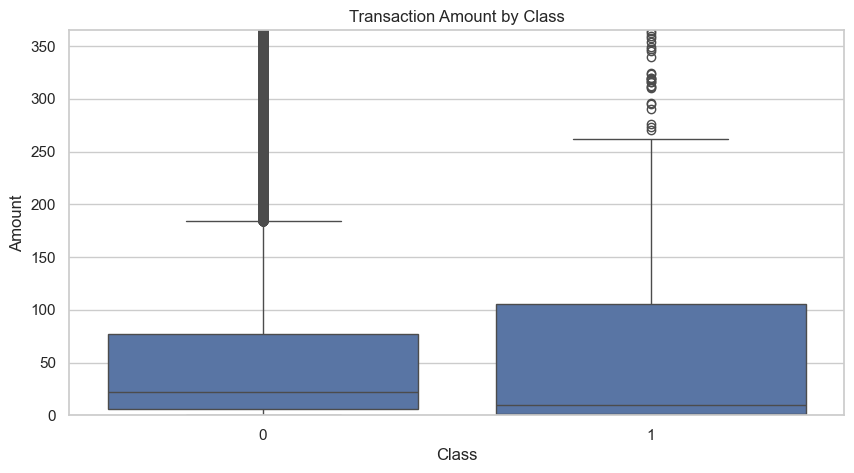

In [20]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")
plt.ylim(0, df["Amount"].quantile(0.95))
plt.show()


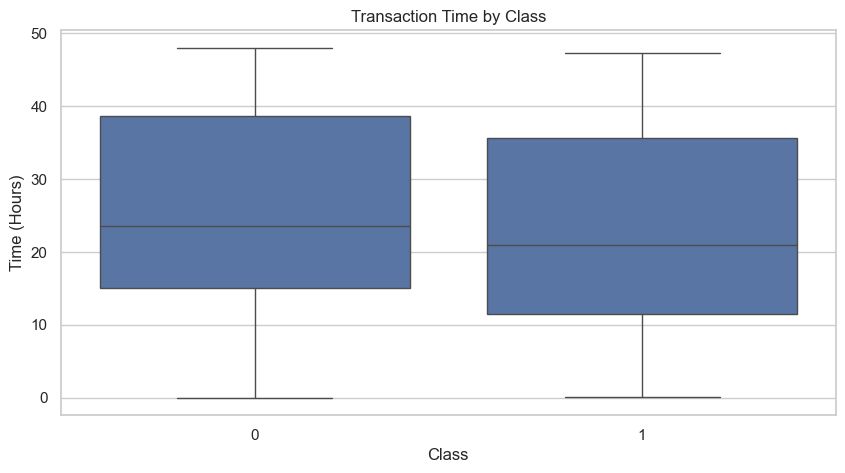

In [21]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="Class", y="Time_Hours", data=df)
plt.title("Transaction Time by Class")
plt.xlabel("Class")
plt.ylabel("Time (Hours)")
plt.show()


In [22]:
# Compare mean values of selected features by class
selected_features = ["Amount", "Time_Hours", "V10", "V12", "V14", "V17"]
mean_by_class = df.groupby("Class")[selected_features].mean().T
mean_by_class.columns = ["Non-Fraud (0)", "Fraud (1)"]
mean_by_class


,Non-Fraud (0),Fraud (1)
Amount,88.2910,122.2113
Time_Hours,26.3439,22.4297
V10,0.0098,-5.6769
V12,0.0108,-6.2594
V14,0.0121,-6.9717
V17,0.0115,-6.6658


## 10. Feature Correlation Analysis

In [23]:
# Correlation of all numeric features with the target variable
corr_with_target = df.corr(numeric_only=True)["Class"].sort_values(key=lambda s: s.abs(), ascending=False)
corr_with_target.to_frame(name="Correlation with Class").head(15)


,Correlation with Class
Class,1.0000
V17,-0.3265
V14,-0.3025
V12,-0.2606
V10,-0.2169
V16,-0.1965
V3,-0.1930
V7,-0.1873
V11,0.1549
V4,0.1334


In [24]:
# Top positively and negatively correlated features
top_positive = corr_with_target.drop("Class").sort_values(ascending=False).head(10)
top_negative = corr_with_target.drop("Class").sort_values().head(10)

display(Markdown("### Top Positive Correlations with Fraud"))
display(top_positive.to_frame(name="Correlation"))

display(Markdown("### Top Negative Correlations with Fraud"))
display(top_negative.to_frame(name="Correlation"))


### Top Positive Correlations with Fraud

,Correlation
V11,0.1549
V4,0.1334
V2,0.0913
V21,0.0404
V19,0.0348
V20,0.0201
V8,0.0199
V27,0.0176
V28,0.0095
Amount,0.0056


### Top Negative Correlations with Fraud

,Correlation
V17,-0.3265
V14,-0.3025
V12,-0.2606
V10,-0.2169
V16,-0.1965
V3,-0.1930
V7,-0.1873
V18,-0.1115
V1,-0.1013
V9,-0.0977


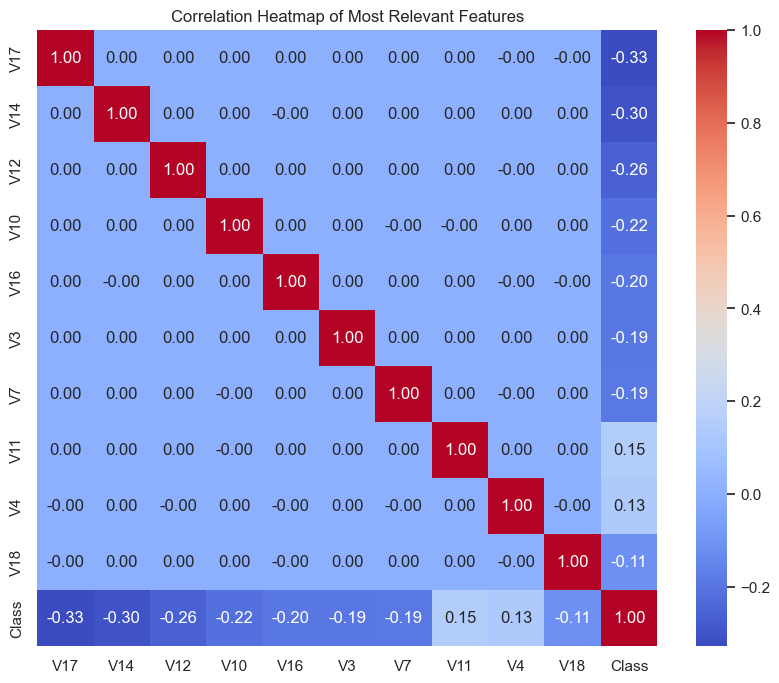

In [25]:
# Heatmap of the most relevant features
top_features = corr_with_target.drop("Class").abs().sort_values(ascending=False).head(10).index.tolist()
heatmap_features = top_features + ["Class"]

plt.figure(figsize=(10, 8))
sns.heatmap(df[heatmap_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Most Relevant Features")
plt.show()


## 11. Key Findings from EDA

Based on the exploratory analysis, the following patterns are clear:

1. The dataset is **highly imbalanced**, with fraud cases representing only a very small fraction of all transactions.
2. There are **no missing values**, which simplifies preprocessing.
3. The **Amount** feature is strongly right-skewed, so scaling or log transformation may be useful for modeling and visualization.
4. Fraud and non-fraud transactions show different behavior in some anonymized features such as **V10, V12, V14, and V17**.
5. The most useful features for fraud detection are likely not raw transaction volume features alone, but the anonymized transformed variables.
6. Because of the severe class imbalance, model evaluation should focus on:
   - Precision
   - Recall
   - F1-score
   - ROC-AUC
   - PR-AUC
7. Accuracy alone will **not** be a reliable metric for this problem.

## 12. Next Steps

After completing EDA, the next phase of the project should include:

1. Train-test split
2. Feature scaling where needed
3. Build baseline models such as:
   - Logistic Regression
   - Random Forest
4. Evaluate models using fraud-sensitive metrics
5. Tune the best-performing model
6. Interpret results and prepare final project conclusions

---

### Final Note
This notebook focuses on **data understanding and exploratory data analysis**.  
It provides the foundation for the next notebook, which can cover **data preprocessing and machine learning modeling**.